In [36]:
import numpy as np
import MDAnalysis as mda
from scipy.spatial import distance
import os
from tqdm import tqdm

In [ ]:
# System definitions
systems = {
    "H3":            {"entry": (786, 839), "exit": (295, 348)},
    "CSH3":          {"entry": (786, 839), "exit": (295, 348)},
    "cenpa":         {"entry": (790, 842), "exit": (295, 347)},
    "CScenpa":       {"entry": (790, 842), "exit": (295, 347)},
    "ltH3core":      {"entry": (785, 837), "exit": (295, 347)},
    "CSltH3core":    {"entry": (785, 837), "exit": (295, 347)},
    "ltcenpacore":   {"entry": (791, 844), "exit": (295, 348)},
    "CSltcenpacore": {"entry": (791, 844), "exit": (295, 348)}
}

cutoff = 4.0
replica_size = 2000
n_replicas = 4
skip = 1

def compute_contacts(u, residue_range):

    dna = u.select_atoms("resid 1:294 and not name H*")
    results = {}

    for resid in tqdm(range(residue_range[0], residue_range[1] + 1), desc="Residues"):
        tail = u.select_atoms(f"resid {resid} and not name H*")

        if len(tail) == 0:
            continue

        replica_means = []

        for rep in range(n_replicas):
            start = rep * replica_size
            stop  = (rep + 1) * replica_size

            contact_sum = 0

            for ts in u.trajectory[start:stop:skip]:
                d = distance.cdist(dna.positions, tail.positions)
                contact_sum += np.sum(d < cutoff)

            replica_means.append(contact_sum / (replica_size/skip))

        replica_means = np.array(replica_means)

        mean = np.mean(replica_means)
        sem  = np.std(replica_means, ddof=1) / np.sqrt(n_replicas)

        results[resid] = (mean, sem)

    return results

# Loop over systems
for system, tails in systems.items():

    print(f"Processing {system}...")

    pdb_file = os.path.join(system, f"{system}_1frame1.pdb")
    xtc_file = os.path.join(system, "total.xtc")

    if not os.path.exists(pdb_file):
        print(f"WARNING: Missing {pdb_file}, skipping.")
        continue

    u = mda.Universe(pdb_file, xtc_file)

    entry_results = compute_contacts(u, tails["entry"])
    exit_results  = compute_contacts(u, tails["exit"])

    entry_file = os.path.join(system, f"{system}_entry_tail_contacts.dat")
    exit_file  = os.path.join(system, f"{system}_exit_tail_contacts.dat")

    with open(entry_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in entry_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    with open(exit_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in exit_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    print(f"{system} done. Files written inside {system}/\n")

Processing H3...


Residues:   0%|          | 0/54 [00:00<?, ?it/s]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

width = 0.28  # bar width

# -----------------------------
# Residue sequences (trimmed)
# -----------------------------
listH3 = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
          'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
          'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
          'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
          'Y41','R42','P43','G44','T45','V46','A47','L48','R49','E50',
          'I51','R52','R53','Y54']

listcenpa = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
             'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
             'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
             'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
             'R41','R42','R43','Q44','G45','W46','L47','K48','E49','I50',
             'R51','K52','L53']

listltH3core = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
                'R41','R42','R43','T44','V45','A46','L47','R48','E49','I50',
                'R51', 'R52', 'Y53']

listltcenpacore = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                   'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                   'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                   'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
                   'Y41','R42','P43','G44','Q45','G46','W47','L48','K49','E50',
                   'I51','R52','K53','L54']

In [26]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# Systems
# -----------------------------
systems = [
    "H3", "cenpa", "ltH3core", "ltcenpacore",
    "CSH3", "CScenpa", "CSltH3core", "CSltcenpacore"
]

# -----------------------------
# Region definitions
# format: (range1, range2)
# -----------------------------
regions = {
    "H3": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "cenpa": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    },
    "ltH3core": {
        "tails": [(295,330), (785,820)],
        "latch": [(331,337), (821,827)],
        "alphaN": [(338,347), (828,837)]
    },
    "ltcenpacore": {
        "tails": [(295,331), (791,827)],
        "latch": [(332,338), (828,834)],
        "alphaN": [(339,348), (835,844)]
    },
    "CSH3": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "CScenpa": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    },
    "CSltH3core": {
        "tails": [(295,330), (785,820)],
        "latch": [(331,337), (821,827)],
        "alphaN": [(338,347), (828,837)]
    },
    "CSltcenpacore": {
        "tails": [(295,331), (791,827)],
        "latch": [(332,338), (828,834)],
        "alphaN": [(339,348), (835,844)]
    }
}

# -----------------------------
# Helper: sum region
# -----------------------------
def compute_region(data, ranges):
    mask = np.zeros(len(data), dtype=bool)

    for start, end in ranges:
        mask |= (data[:,0] >= start) & (data[:,0] <= end)

    selected = data[mask]

    total_contacts = np.sum(selected[:,1])
    total_sem = np.sqrt(np.sum(selected[:,2]**2))

    return total_contacts, total_sem

# -----------------------------
# Main loop
# -----------------------------
results = []

for system in systems:
    for tail_type in ["entry", "exit"]:
        filepath = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")

        if not os.path.exists(filepath):
            continue

        data = np.loadtxt(filepath, comments="#")

        for region_name, ranges in regions[system].items():
            total, sem = compute_region(data, ranges)

            results.append([
                system,
                tail_type,
                region_name,
                total,
                sem
            ])

# -----------------------------
# Save output
# -----------------------------
df = pd.DataFrame(results, columns=[
    "System", "Tail", "Region", "TotalContacts", "SEM"
])

df.to_csv("cumulative_tail_contacts.dat", index=False, sep="\t")

print("Done! Output: cumulative_tail_contacts.dat")

Done! Output: cumulative_tail_contacts.dat


/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/3056190007.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/3056190007.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


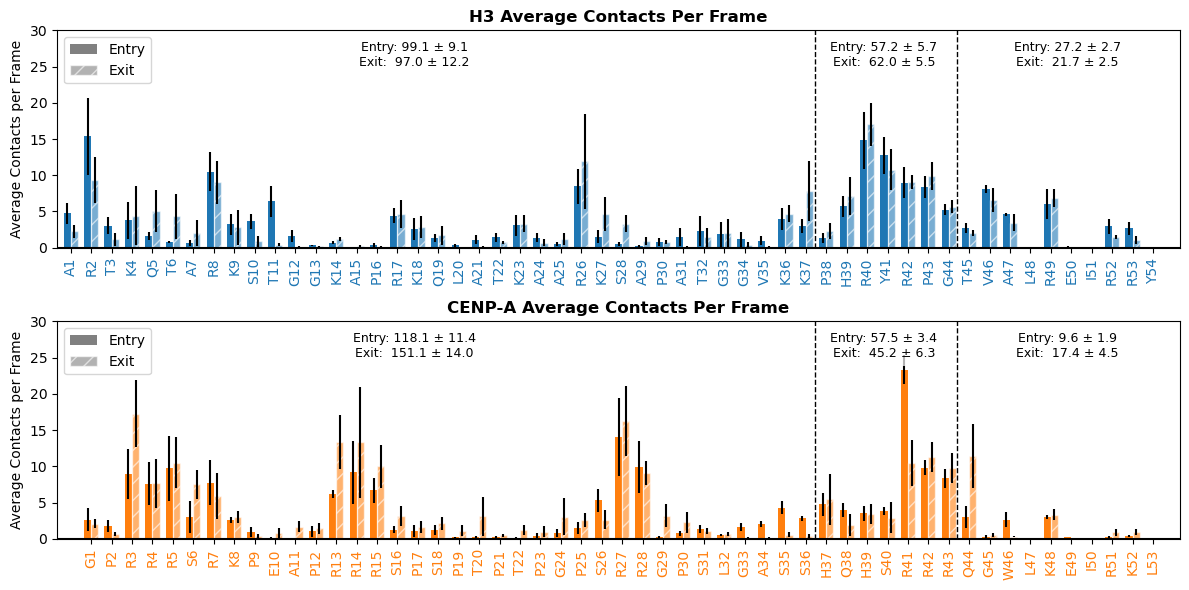

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None, subtitle=None,
                remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], color=color,
                   alpha=exit_alpha, hatch='//', edgecolor='white')

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 30)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        # Region centers
        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='gray', alpha=exit_alpha, label="Exit",
              hatch='//', edgecolor='white')
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3, ste_entry_H3 = load_tail_data("H3", "entry")
avg_exit_H3, ste_exit_H3 = load_tail_data("H3", "exit")

avg_entry_cenpa, ste_entry_cenpa = load_tail_data("cenpa", "entry")
avg_exit_cenpa, ste_exit_cenpa = load_tail_data("cenpa", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3)

avg_entry_cenpa_plot = [0] + list(avg_entry_cenpa)
ste_entry_cenpa_plot = [0] + list(ste_entry_cenpa)
avg_exit_cenpa_plot = [0] + list(avg_exit_cenpa)
ste_exit_cenpa_plot = [0] + list(ste_exit_cenpa)
labels_cenpa_plot = [""] + list(listcenpa)

highlight_H3 = {}
highlight_cenpa = {}

# -----------------------------
# Generate figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

plot_system(
    axes[0],
    avg_entry_H3, ste_entry_H3,
    avg_exit_H3, ste_exit_H3,
    listH3,
    tab20(0),
    subtitle="H3 Average Contacts Per Frame",
    system_name="H3"
)

plot_system(
    axes[1],
    avg_entry_cenpa_plot, ste_entry_cenpa_plot,
    avg_exit_cenpa_plot, ste_exit_cenpa_plot,
    labels_cenpa_plot,
    tab20(2),
    subtitle="CENP-A Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="cenpa"
)

plt.tight_layout()
plt.savefig('wildtype_AA_WIDOM_BYRES_CONTACTS.pdf')
plt.savefig('wildtype_AA_WIDOM_BYRES_CONTACTS.png')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/3911729766.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/3911729766.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


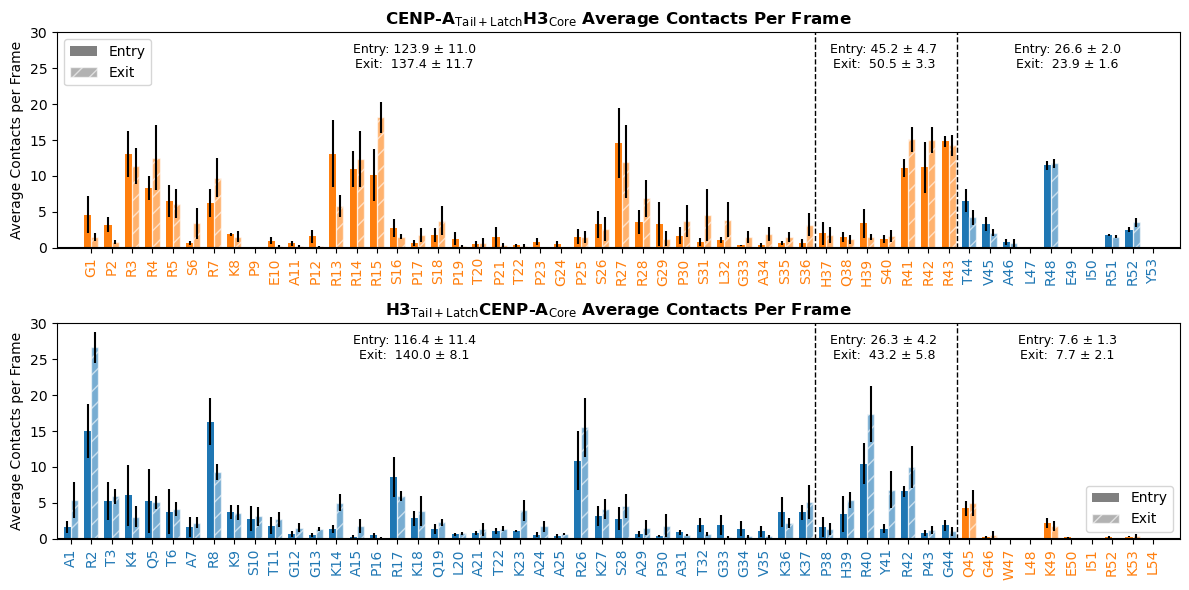

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], color=color,
                   alpha=exit_alpha, hatch='//', edgecolor='white')

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 30)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='gray', alpha=exit_alpha, label="Exit",
              hatch='//', edgecolor='white')
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listltcenpacore) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_ltH3core, ste_entry_ltH3core = load_tail_data("ltH3core", "entry")
avg_exit_ltH3core, ste_exit_ltH3core = load_tail_data("ltH3core", "exit")
avg_entry_ltcenpacore, ste_entry_ltcenpacore = load_tail_data("ltcenpacore", "entry")
avg_exit_ltcenpacore, ste_exit_ltcenpacore = load_tail_data("ltcenpacore", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_ltH3core = len(listltH3core)
num_ltcenpacore = len(listltcenpacore)
num_slots = len(listltcenpacore)

avg_entry_ltH3core_plot = [0] + list(avg_entry_ltH3core)
ste_entry_ltH3core_plot = [0] + list(ste_entry_ltH3core)
avg_exit_ltH3core_plot = [0] + list(avg_exit_ltH3core)
ste_exit_ltH3core_plot = [0] + list(ste_exit_ltH3core)
labels_ltH3core_plot = [""] + list(listltH3core)

avg_entry_ltcenpacore_plot = list(avg_entry_ltcenpacore)
ste_entry_ltcenpacore_plot = list(ste_entry_ltcenpacore)
avg_exit_ltcenpacore_plot = list(avg_exit_ltcenpacore)
ste_exit_ltcenpacore_plot = list(ste_exit_ltcenpacore)
labels_ltcenpacore_plot = list(listltcenpacore)

highlight_ltH3core = {i: tab20(2) for i in range(1,44)}
highlight_ltcenpacore = {i: tab20(0) for i in range(0,44)}

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

plot_system(
    axes[0],
    avg_entry_ltH3core_plot, ste_entry_ltH3core_plot,
    avg_exit_ltH3core_plot, ste_exit_ltH3core_plot,
    labels_ltH3core_plot, tab20(0),
    highlight=highlight_ltH3core,
    subtitle=r"CENP-A$_{\mathrm{Tail+Latch}}$H3$_{\mathrm{Core}}$ Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="ltH3core"
)

plot_system(
    axes[1],
    avg_entry_ltcenpacore_plot, ste_entry_ltcenpacore_plot,
    avg_exit_ltcenpacore_plot, ste_exit_ltcenpacore_plot,
    labels_ltcenpacore_plot, tab20(2),
    highlight=highlight_ltcenpacore,
    subtitle=r"H3$_{\mathrm{Tail+Latch}}$CENP-A$_{\mathrm{Core}}$ Average Contacts Per Frame",
    system_name="ltcenpacore"
)

plt.tight_layout()
plt.savefig('tail+latch_AA_WIDOM_BYRES_CONTACTS.pdf')
plt.savefig('tail+latch_AA_WIDOM_BYRES_CONTACTS.png')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/2680465059.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/2680465059.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


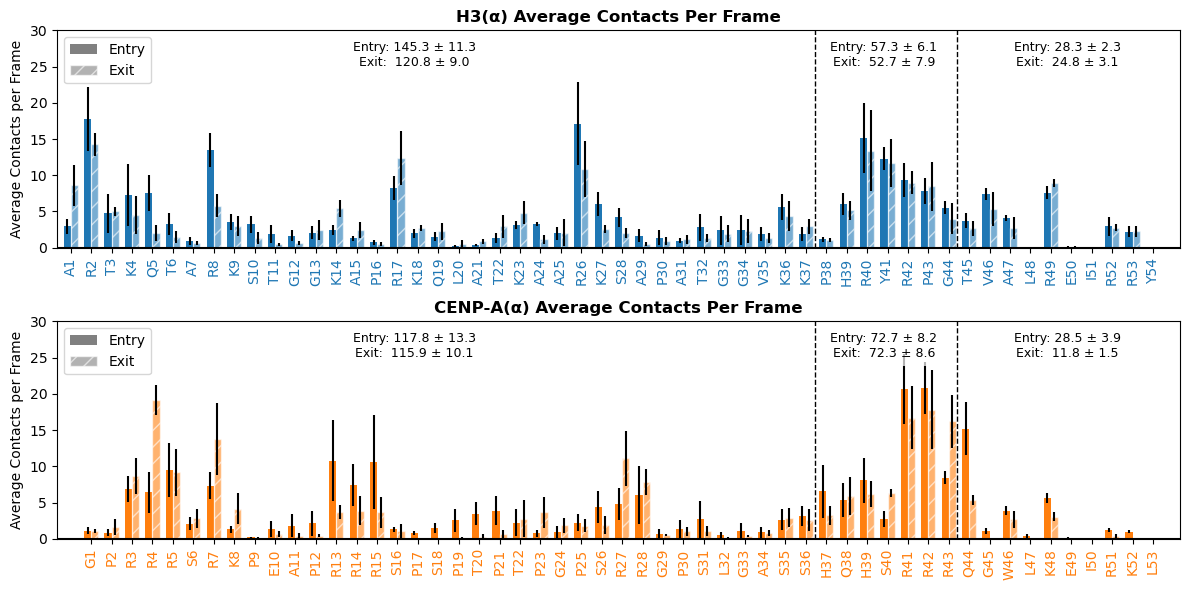

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], color=color,
                   alpha=exit_alpha, hatch='//', edgecolor='white')

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 30)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='gray', alpha=exit_alpha, label="Exit",
              hatch='//', edgecolor='white')
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_CSH3, ste_entry_CSH3 = load_tail_data("CSH3", "entry")
avg_exit_CSH3, ste_exit_CSH3 = load_tail_data("CSH3", "exit")
avg_entry_CScenpa, ste_entry_CScenpa = load_tail_data("CScenpa", "entry")
avg_exit_CScenpa, ste_exit_CScenpa = load_tail_data("CScenpa", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_CSH3 = len(listH3)
num_CScenpa = len(listcenpa)

num_slots = len(listH3)

avg_entry_CScenpa_plot = [0] + list(avg_entry_CScenpa)
ste_entry_CScenpa_plot = [0] + list(ste_entry_CScenpa)
avg_exit_CScenpa_plot = [0] + list(avg_exit_CScenpa)
ste_exit_CScenpa_plot = [0] + list(ste_exit_CScenpa)
labels_CScenpa_plot = [""] + list(listcenpa)

highlight_CSH3 = {}
highlight_CScenpa = {}

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

plot_system(
    axes[0],
    avg_entry_CSH3, ste_entry_CSH3,
    avg_exit_CSH3, ste_exit_CSH3,
    listH3,
    tab20(0),
    subtitle="H3(α) Average Contacts Per Frame",
    system_name="CSH3"
)

plot_system(
    axes[1],
    avg_entry_CScenpa_plot, ste_entry_CScenpa_plot,
    avg_exit_CScenpa_plot, ste_exit_CScenpa_plot,
    labels_CScenpa_plot,
    tab20(2),
    subtitle="CENP-A(α) Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="CScenpa"
)

plt.tight_layout()
plt.savefig('wildtype_AA_CENTROMERIC_BYRES_CONTACTS.pdf')
plt.savefig('wildtype_AA_CENTROMERIC_WIDOM_BYRES_CONTACTS.png')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/1232592882.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_27463/1232592882.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


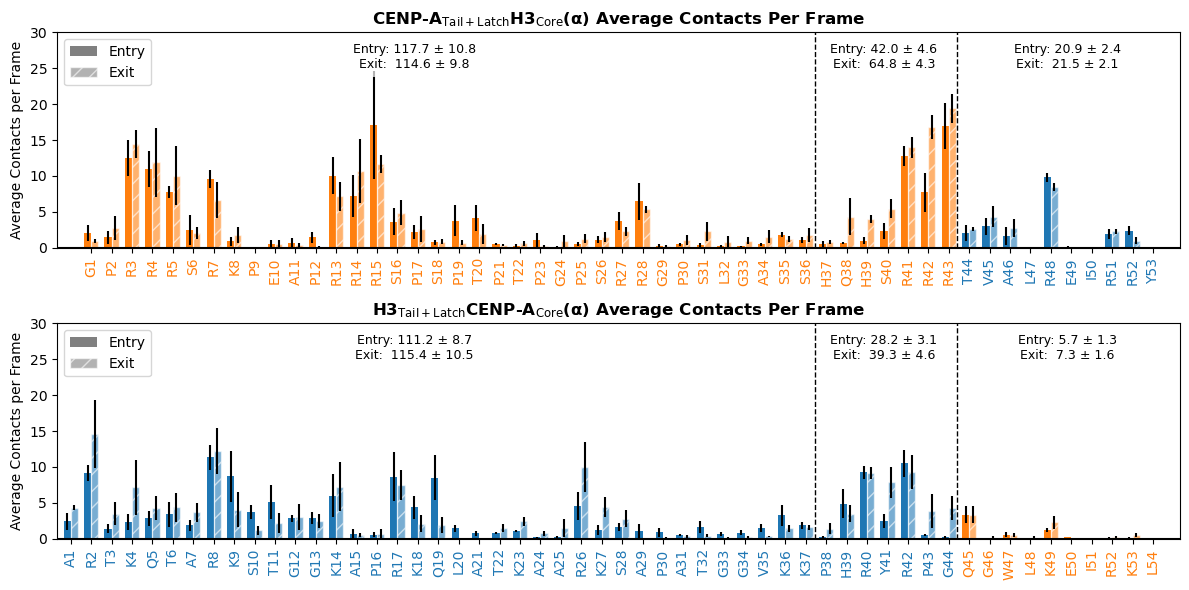

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], color=color,
                   alpha=exit_alpha, hatch='//', edgecolor='white')

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 30)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='gray', alpha=exit_alpha, label="Exit",
              hatch='//', edgecolor='white')
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listltcenpacore) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_CSltH3core, ste_entry_CSltH3core = load_tail_data("CSltH3core", "entry")
avg_exit_CSltH3core, ste_exit_CSltH3core = load_tail_data("CSltH3core", "exit")
avg_entry_CSltcenpacore, ste_entry_CSltcenpacore = load_tail_data("CSltcenpacore", "entry")
avg_exit_CSltcenpacore, ste_exit_CSltcenpacore = load_tail_data("CSltcenpacore", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_CSltH3core = len(listltH3core)
num_CSltcenpacore = len(listltcenpacore)
num_slots = len(listltcenpacore)

avg_entry_CSltH3core_plot = [0] + list(avg_entry_CSltH3core)
ste_entry_CSltH3core_plot = [0] + list(ste_entry_CSltH3core)
avg_exit_CSltH3core_plot = [0] + list(avg_exit_CSltH3core)
ste_exit_CSltH3core_plot = [0] + list(ste_exit_CSltH3core)
labels_CSltH3core_plot = [""] + list(listltH3core)

avg_entry_CSltcenpacore_plot = list(avg_entry_CSltcenpacore)
ste_entry_CSltcenpacore_plot = list(ste_entry_CSltcenpacore)
avg_exit_CSltcenpacore_plot = list(avg_exit_CSltcenpacore)
ste_exit_CSltcenpacore_plot = list(ste_exit_CSltcenpacore)
labels_CSltcenpacore_plot = list(listltcenpacore)

highlight_CSltH3core = {i: tab20(2) for i in range(1,44)}
highlight_CSltcenpacore = {i: tab20(0) for i in range(0,44)}

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

plot_system(
    axes[0],
    avg_entry_CSltH3core_plot, ste_entry_CSltH3core_plot,
    avg_exit_CSltH3core_plot, ste_exit_CSltH3core_plot,
    labels_CSltH3core_plot, tab20(0),
    highlight=highlight_CSltH3core,
    subtitle=r"CENP-A$_{\mathrm{Tail+Latch}}$H3$_{\mathrm{Core}}$(α) Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="CSltH3core"
)

plot_system(
    axes[1],
    avg_entry_CSltcenpacore_plot, ste_entry_CSltcenpacore_plot,
    avg_exit_CSltcenpacore_plot, ste_exit_CSltcenpacore_plot,
    labels_CSltcenpacore_plot, tab20(2),
    highlight=highlight_CSltcenpacore,
    subtitle=r"H3$_{\mathrm{Tail+Latch}}$CENP-A$_{\mathrm{Core}}$(α) Average Contacts Per Frame",
    system_name="CSltcenpacore"
)

plt.tight_layout()
plt.savefig('tail+latch_AA_CENTROMERIC_BYRES_CONTACTS.pdf')
plt.savefig('tail+latch_AA_CENTROMERIC_BYRES_CONTACTS.png')
plt.show()